In [1]:
# Hex grid — three densities (regular / extra / super).
# Pointy-top hexagons centered on the same triangular lattice as isometric.
# Per pointy-top tessellation math, vertex offsets from center are:
#   top:    (0,        -2P_y/3)
#   ur:     (+P_x/2,   -P_y/3)
#   lr:     (+P_x/2,   +P_y/3)
#   bot:    (0,        +2P_y/3)
#   ll:     (-P_x/2,   +P_y/3)
#   ul:     (-P_x/2,   -P_y/3)
# These are derived from the centroid of three mutually adjacent hex
# centers, so adjacent hexes share vertices EXACTLY (algebraically).
#
# CONSTRAINT CONFLICT (same as isometric, plus one more):
#   1. True 60° hexagons require P_y = P_x*sqrt(3)/2 — irrational. We use
#      the iso-lattice approximations (< 1.2° angular deviation).
#   2. P_y/3 is integer only when P_y is divisible by 3 — only P_y=210
#      satisfies this here. For P_y=125 and P_y=100, vertex offsets are
#      fractional; we pass floats to PIL and let its anti-aliasing handle
#      the sub-pixel rendering. Adjacent hexes still share the EXACT same
#      float vertex (not a rounded version), so tessellation is seamless.
#
# Output: ../output/hex/{hex,extra-hex,super-hex}.png
from PIL import Image, ImageDraw
from IPython.display import display
from common import (
    blank_page, draw_header, FG_COLOR, ELEM_SIZE,
    LATTICE_W, LATTICE_H, MARGIN, HEADER_HEIGHT,
    output_path, variant_name,
)

MODE = "hex"

# Same (P_x, P_y) as isometric — hex centers form the iso lattice.
HEX = {
    "regular": (250, 210),   # P_y/3=70.0 (integer)
    "extra":   (150, 125),   # P_y/3≈41.67 (sub-pixel vertices)
    "super":   (110, 100),   # P_y/3≈33.33 (sub-pixel vertices)
}

In [2]:
def hex_vertices(cx, cy, P_x, P_y):
    """Six pointy-top hex vertices in CCW order, returning to the start."""
    hx = P_x / 2
    hy = P_y / 3
    return [
        (cx,        cy - 2 * hy),
        (cx + hx,   cy - hy),
        (cx + hx,   cy + hy),
        (cx,        cy + 2 * hy),
        (cx - hx,   cy + hy),
        (cx - hx,   cy - hy),
        (cx,        cy - 2 * hy),  # close the loop for joint='curve'
    ]


def render_hex(P_x, P_y):
    """Tile the usable rectangle with pointy-top hexes centered on the
    iso lattice. Even rows at x = MARGIN + i*P_x; odd rows offset by P_x/2."""
    assert P_x % 2 == 0
    assert LATTICE_W % P_x == 0 and LATTICE_H % P_y == 0
    n_x_even = LATTICE_W // P_x + 1
    n_x_odd  = n_x_even - 1
    n_y      = LATTICE_H // P_y + 1
    half     = P_x // 2
    img = blank_page()
    draw = ImageDraw.Draw(img)
    count = 0
    for j in range(n_y):
        cy = HEADER_HEIGHT + MARGIN + j * P_y
        if j % 2 == 0:
            xs = [MARGIN + i * P_x for i in range(n_x_even)]
        else:
            xs = [MARGIN + half + i * P_x for i in range(n_x_odd)]
        for cx in xs:
            verts = hex_vertices(cx, cy, P_x, P_y)
            draw.line(verts, fill=FG_COLOR, width=ELEM_SIZE, joint="curve")
            count += 1
    draw_header(img)
    return img, n_y, count

regular  P_x=250  P_y=210  rows= 51  hexes= 1709  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/hex.png


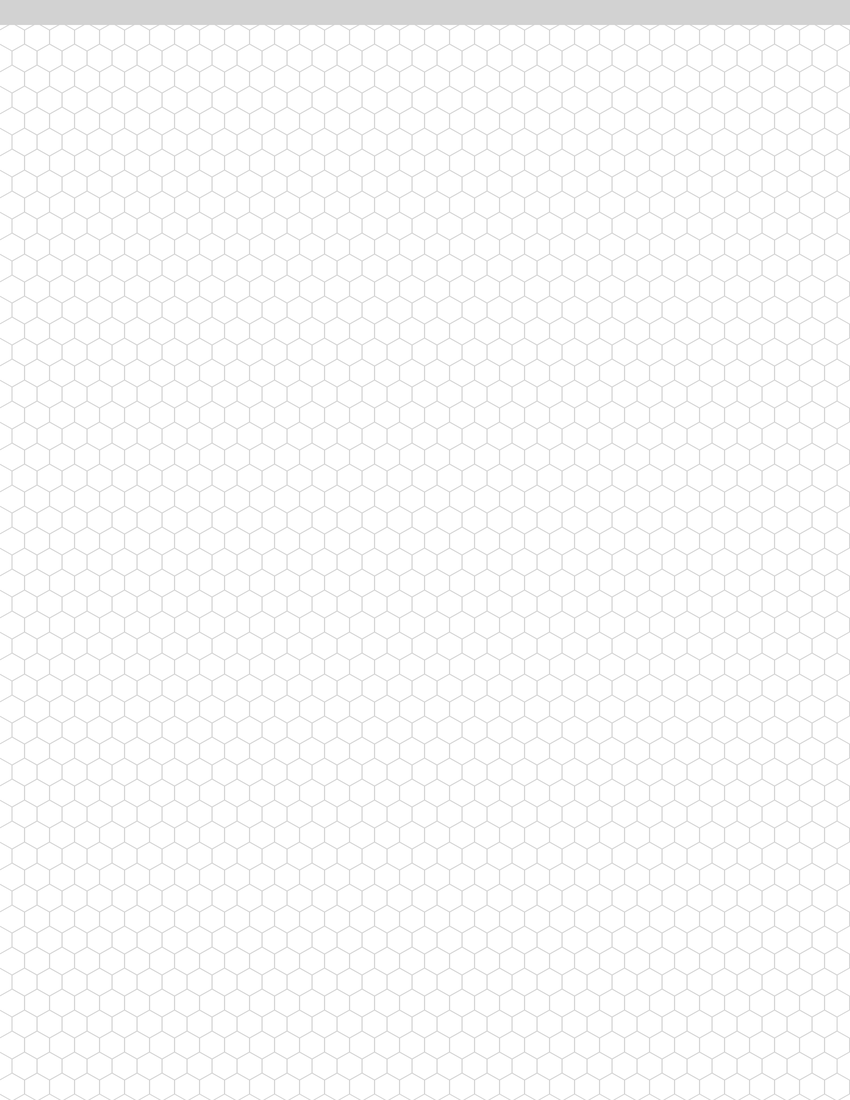

extra    P_x=150  P_y=125  rows= 85  hexes= 4718  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/extra-hex.png


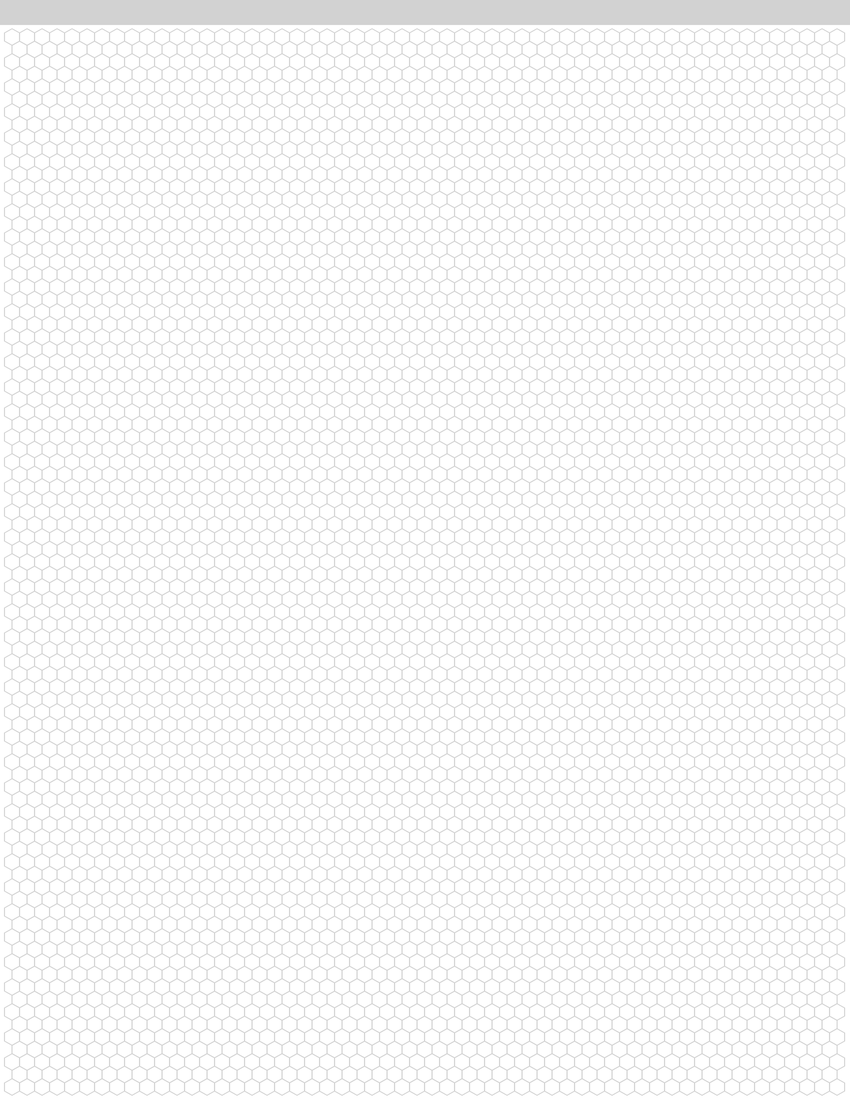

super    P_x=110  P_y=100  rows=106  hexes= 8003  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/super-hex.png


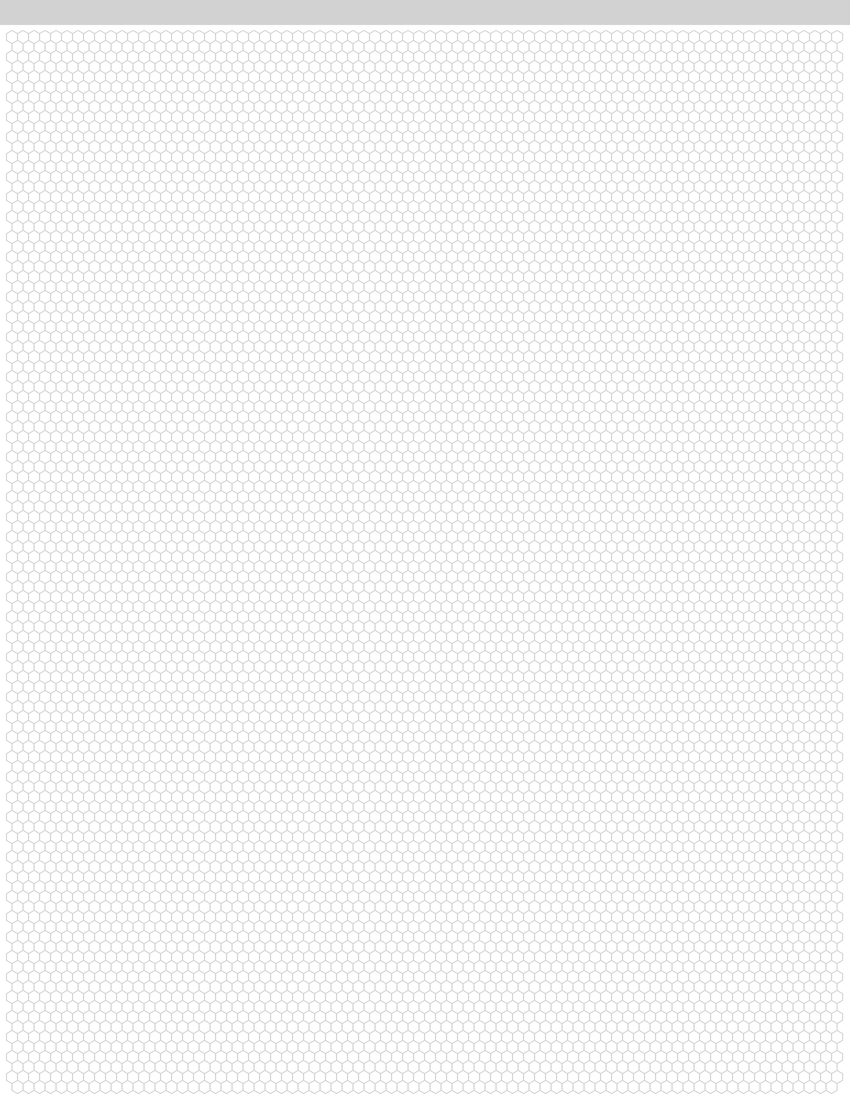

In [3]:
for density, (P_x, P_y) in HEX.items():
    img, n_y, count = render_hex(P_x, P_y)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} P_x={P_x:3d}  P_y={P_y:3d}  rows={n_y:3d}  "
        f"hexes={count:5d}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))